In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)

import shap
from functools import partial


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

import joblib
from utils.utils import feature_engineering

## 1 · Carga de datos y Split


In [2]:
RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 60)

DATA_PATH = 'data/raw/novapay_transacciones.csv'
df_raw = pd.read_csv(DATA_PATH)
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (100000, 18)


,id_transaccion,id_usuario,fecha,hora,dias_antiguedad_cuenta,email_verificado,pais_emision,categoria,importe,es_online,pais_pago,tipo_tarjeta,mismo_envio_facturacion,tipo_dispositivo,uso_vpn_proxy,paso_3d_secure,minutos_desde_ultima_tx,es_fraude
0,322018a1-24ae-4c31-7d85-a873a8e4f69a,756a9a6d-0a72-5b57-2d6b-f721eabc6efa,2025-01-01 00:00:00,0,0,1,GB,Supermercado,58.37,1,GB,Débito,1,Móvil,0,1,363.6,0
1,4fcee3c3-4c61-eef8-531b-50dcc3561152,6bfab445-eb98-1ba0-519c-81ac6d53d972,2025-01-01 00:09:00,0,268,1,BR,Supermercado,88.18,1,BR,Crédito,0,Móvil,0,0,779.3,0
2,31b0946c-5282-3ca2-4503-f2b16b395875,3bd3290a-b74e-64dd-6473-20f2d130c7e5,2025-01-01 00:12:00,0,641,1,FR,Electrónica,11.29,1,FR,Crédito,1,Tablet,0,0,1059.6,0
3,7f62d465-740c-7aea-1796-d0bcd44ab299,75957b92-bdc4-1feb-3325-8d75b19f7ae3,2025-01-01 00:13:00,0,0,1,DE,Electrónica,587.66,1,DE,Crédito,1,Móvil,0,1,763.2,0
4,346d7ab9-88d3-891c-08b4-de0c83c6bfe9,3e7266c5-4e26-87fd-2079-9e085a6b0964,2025-01-01 00:20:00,0,0,1,ES,Suscripciones,335.41,1,CN,Crédito,0,Móvil,0,0,166.2,1


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id_transaccion           100000 non-null  str    
 1   id_usuario               100000 non-null  str    
 2   fecha                    100000 non-null  str    
 3   hora                     100000 non-null  int64  
 4   dias_antiguedad_cuenta   100000 non-null  int64  
 5   email_verificado         100000 non-null  int64  
 6   pais_emision             100000 non-null  str    
 7   categoria                100000 non-null  str    
 8   importe                  100000 non-null  float64
 9   es_online                100000 non-null  int64  
 10  pais_pago                100000 non-null  str    
 11  tipo_tarjeta             100000 non-null  str    
 12  mismo_envio_facturacion  100000 non-null  int64  
 13  tipo_dispositivo         100000 non-null  str    
 14  uso_vpn_proxy   

In [4]:
# Numéricas
num_cols = [
    'hora',
    'dias_antiguedad_cuenta',
    'importe',
    'minutos_desde_ultima_tx'
]

# Categóricas
cat_cols = [
    'pais_emision',
    'pais_pago',
    'categoria',
    'tipo_tarjeta',
    'tipo_dispositivo'
]

In [5]:
df_raw['minutos_desde_ultima_tx'].describe()

count    100000.000000
mean      58867.786407
std       84616.008353
min           0.000000
25%        4868.000000
50%       24076.500000
75%       76207.000000
max      526328.900000
Name: minutos_desde_ultima_tx, dtype: float64

## 2 · EDA


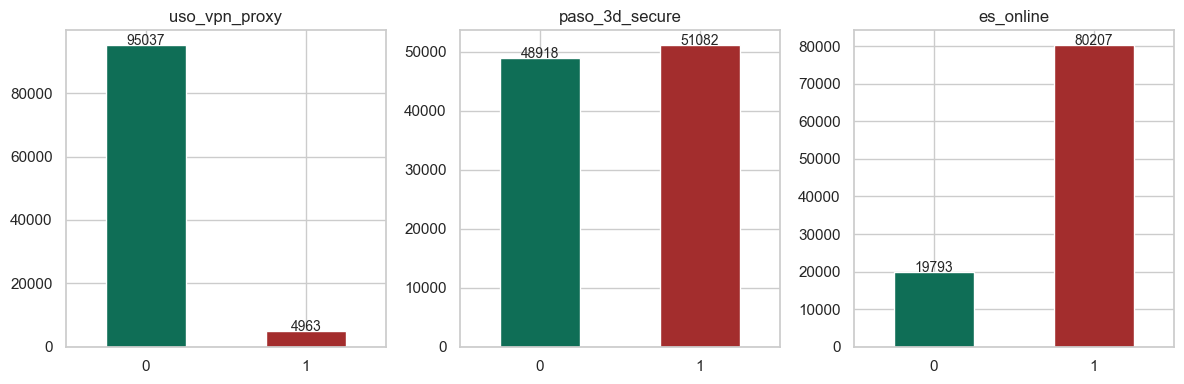

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, ['uso_vpn_proxy', 'paso_3d_secure', 'es_online']):
    df_raw[col].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#0F6E56', '#A32D2D'])
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 100, 
                f'{int(p.get_height())}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

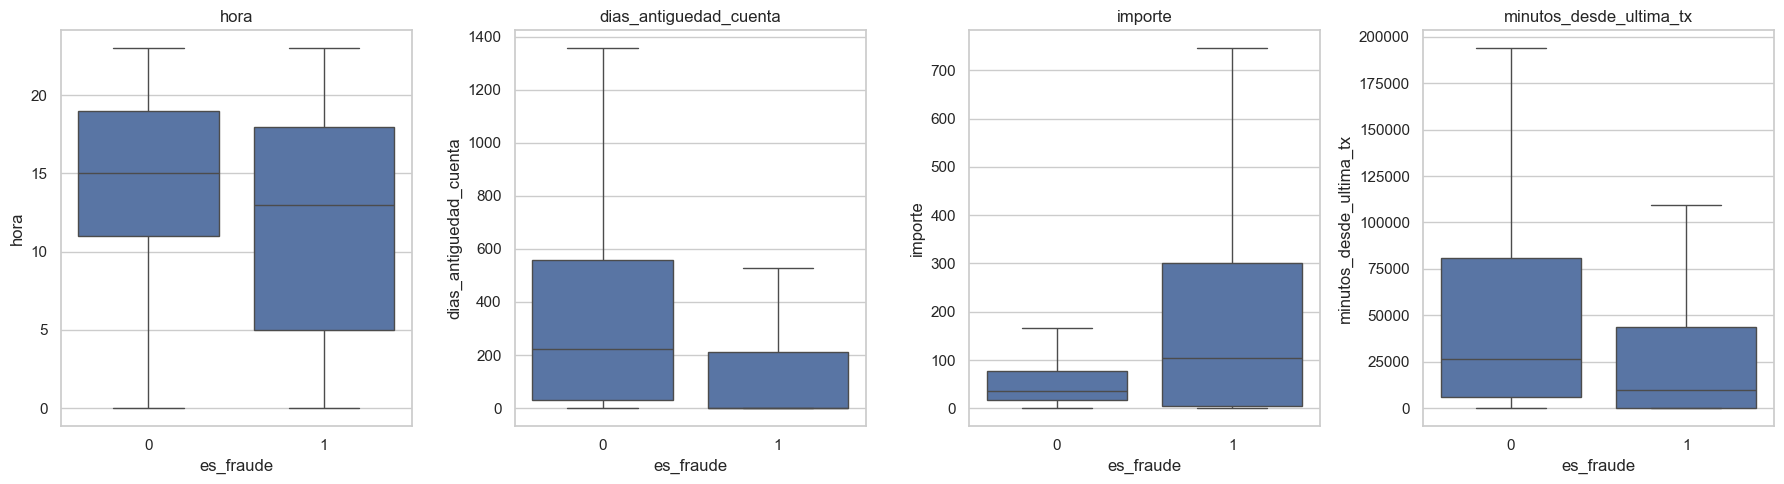

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes.flat, num_cols):
    # boxplot por target
    sns.boxplot(data=df_raw, x='es_fraude', y=col, ax=ax, showfliers=False)
    ax.set_title(col)
plt.tight_layout(); plt.show()

In [8]:
def fraud_rate_by(col, df=None, top=15):
    if df is None:
        df = df_raw
    out = df.groupby(col, dropna=False)['es_fraude'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    out['mean'] = (out['mean'] * 100).round(2)
    out.columns = ['fraude_%', 'n']
    return out.head(top)

for c in ['tipo_tarjeta', 'tipo_dispositivo', 'pais_emision', 'pais_pago', 'categoria']:
    print(f'\n=== {c} ===')
    print(fraud_rate_by(c))


=== tipo_tarjeta ===
              fraude_%      n
tipo_tarjeta                 
Prepago          49.47   8635
Crédito           9.25  38734
Débito            8.08  52631

=== tipo_dispositivo ===
                  fraude_%      n
tipo_dispositivo                 
Desktop              24.32  25171
Tablet               12.75   5552
Móvil                 9.72  49484
Físico (TPV)          2.36  19793

=== pais_emision ===
              fraude_%      n
pais_emision                 
FR               14.49   7917
GB               13.20   4168
DE               12.92   6850
ES               12.35  54433
IT               11.89   4391
IN               11.67   1071
MX               11.53   2905
CN               11.48   1908
JP               10.64    677
US               10.59   5070
PT               10.55   6466
BR                9.99   1501
RU                6.17   2643

=== pais_pago ===
           fraude_%      n
pais_pago                 
IN            50.73   1782
CN            43.06   2729

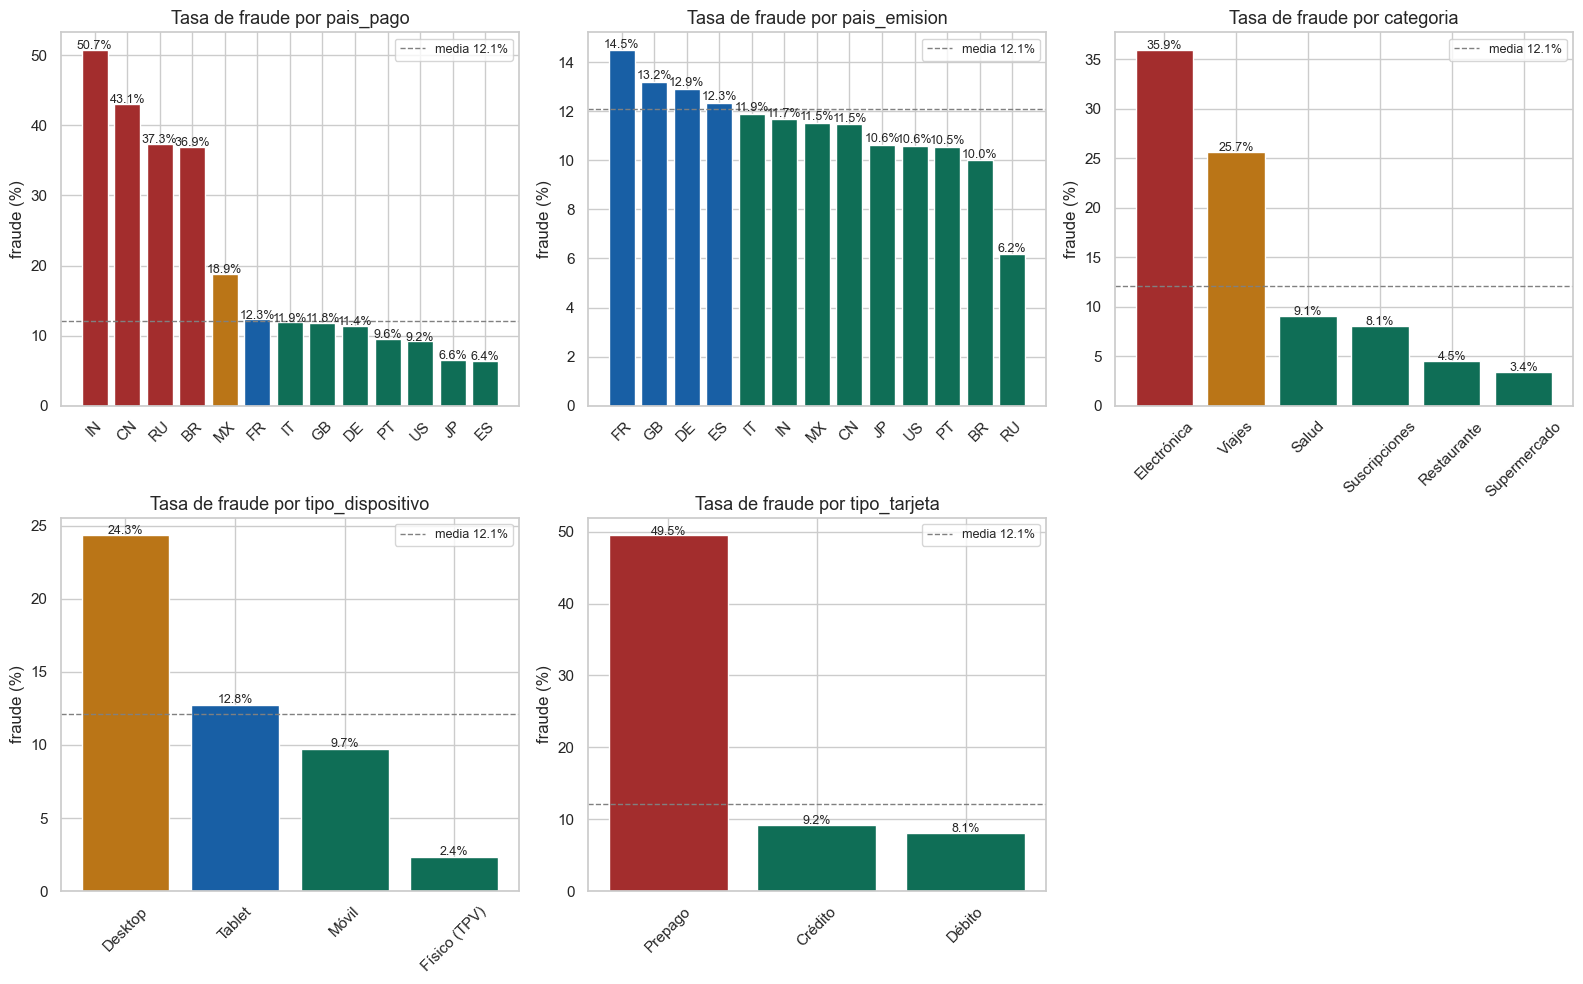

In [9]:
def plot_fraud_rate(col, df, top=15, ax=None):
    data = df.groupby(col)['es_fraude'].mean().sort_values(ascending=False).head(top) * 100
    
    # Umbrales relativos a la tasa base del dataset
    base = df['es_fraude'].mean() * 100
    colors = [
        '#A32D2D' if v >= base * 2.5 else   # >2.5x la media → rojo
        '#BA7517' if v >= base * 1.5 else   # >1.5x la media → naranja  
        '#185FA5' if v >= base else          # >media → azul
        '#0F6E56'                            # <media → verde
        for v in data.values
    ]
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    
    ax.bar(data.index, data.values, color=colors)
    ax.axhline(y=base, color='gray', linestyle='--', linewidth=1, label=f'media {base:.1f}%')
    ax.set_title(f'Tasa de fraude por {col}', fontsize=13)
    ax.set_ylabel('fraude (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)
    
    for i, v in enumerate(data.values):
        ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)
    
    return ax

cols = ['pais_pago', 'pais_emision', 'categoria', 'tipo_dispositivo', 'tipo_tarjeta']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    plot_fraud_rate(col, df_raw, ax=axes[i])

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('data/reports/eda_fraud_rates.png', dpi=150, bbox_inches='tight')
plt.show()

### 3 insights clave:

- pais_pago RU/CN/IN: tasa 8-10% vs ES 0.9% -> feature pago_pais_alto_riesgo muy potente
- Electrónica: 4.62% vs media 2% -> feature categoria_riesgo
- Tipo de tarjeta: diferencia mínima -> feature de bajo valor predictivo

Nota: No eliminaremos tipo_tarjeta, aunque no aporta mucho al modelo, lo veremos en SHAP.

### Columnas que deben ser elimiandas.

- id_transaccion
- id_usuario

In [10]:
df_raw = df_raw.drop(columns=['id_transaccion', 'id_usuario'])

### Dividimos en Train y Test para comenzar el tratamiento del Train

In [11]:
TARGET = 'es_fraude'

X = df_raw.drop(columns=[TARGET])
y = df_raw[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, ' fraude=', y_train.mean().round(4))
print('Test :', X_test.shape, ' fraude=', y_test.mean().round(4))

Train: (80000, 15)  fraude= 0.1211
Test : (20000, 15)  fraude= 0.1211


## 3 · Feature Engineering

In [12]:
# === Feature Engineering manual (DEPRECADO) ===
# Todo el feature engineering ahora lo hace exclusivamente utils.py::feature_engineering
# dentro del pipeline (paso 'fe' del ImbPipeline).
# Las siguientes líneas se conservan comentadas como referencia histórica.
#
# df_train = X_train.copy()
#
# # Fecha
# df_train['fecha'] = pd.to_datetime(df_train['fecha'])
# df_train['dia_semana'] = df_train['fecha'].dt.dayofweek      # 0=lunes, 6=domingo
# df_train['es_fin_de_semana'] = (df_train['dia_semana'] >= 5).astype(int)
# df_train['mes'] = df_train['fecha'].dt.month
# df_train = df_train.drop(columns=['fecha'])
#
# # País
# df_train['pais_alto_riesgo'] = df_train['pais_pago'].isin(['RU','CN','IN']).astype(int)
# df_train['pais_distinto'] = (df_train['pais_emision'] != df_train['pais_pago']).astype(int)
#
# # Hora
# df_train['hora_madrugada'] = df_train['hora'].between(0, 5).astype(int)  # 0 a 5 am devuelve 1
#
# # Categoría
# df_train['categoria_alto_riesgo'] = (df_train['categoria'] == 'Electrónica').astype(int)
#
# # Combinaciones
# df_train['online_sin_3ds'] = ((df_train['es_online'] == 1) & (df_train['paso_3d_secure'] == 0)).astype(int)

## 4 · Pipeline: OHE + Scaling + SMOTE

In [13]:
num_cols = ['hora', 'dias_antiguedad_cuenta', 'importe', 'minutos_desde_ultima_tx']
cat_cols = [
    'pais_emision',
    'pais_pago', 
    'categoria',
    'tipo_tarjeta',
    'tipo_dispositivo'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'
)

In [14]:
# Listas de alto riesgo derivadas SOLO desde el training set (evita leakage del EDA)
_tasas_pais = pd.concat([X_train['pais_pago'], y_train], axis=1).groupby('pais_pago')['es_fraude'].mean()
paises_alto_riesgo = tuple(_tasas_pais[_tasas_pais > 0.05].index.tolist())

_tasas_cat = pd.concat([X_train['categoria'], y_train], axis=1).groupby('categoria')['es_fraude'].mean()
categorias_alto_riesgo = tuple(_tasas_cat[_tasas_cat > 0.03].index.tolist())

print('Países alto riesgo (derivados de train):', paises_alto_riesgo)
print('Categorías alto riesgo (derivadas de train):', categorias_alto_riesgo)

pipeline = ImbPipeline(steps=[
    ('fe', FunctionTransformer(
        feature_engineering,
        validate=False,
        kw_args={
            'paises_alto_riesgo': paises_alto_riesgo,
            'categorias_alto_riesgo': categorias_alto_riesgo,
        },
    )),
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', XGBClassifier(random_state=RANDOM_STATE))
])

Países alto riesgo (derivados de train): ('BR', 'CN', 'DE', 'ES', 'FR', 'GB', 'IN', 'IT', 'JP', 'MX', 'PT', 'RU', 'US')
Categorías alto riesgo (derivadas de train): ('Electrónica', 'Restaurante', 'Salud', 'Supermercado', 'Suscripciones', 'Viajes')


## 5 · Entrenamiento de XGBoost

In [15]:
# --- XGBoost ---
xgb_params = {
    'clf__n_estimators': [300, 500, 800, 1200],
    'clf__max_depth':    [4, 5, 6, 7, 8],
    'clf__learning_rate':[0.02, 0.05, 0.08, 0.1],
    'clf__subsample':    [0.7, 0.8, 0.9, 1.0],
    'clf__colsample_bytree':[0.6, 0.8, 1.0],
    'clf__min_child_weight':[1, 3, 5, 10],
    'clf__gamma':       [0, 0.1, 0.5, 1.0],
    'clf__reg_lambda':  [0.5, 1.0, 2.0, 5.0],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rs_xgb = RandomizedSearchCV(
    pipeline,
    xgb_params,
    n_iter=25,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)
rs_xgb.fit(X_train, y_train)

print('Mejor PR-AUC XGB:', rs_xgb.best_score_.round(4))
print('Mejor combo:', rs_xgb.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Mejor PR-AUC XGB: 0.9716
Mejor combo: {'clf__subsample': 0.8, 'clf__reg_lambda': 1.0, 'clf__n_estimators': 500, 'clf__min_child_weight': 5, 'clf__max_depth': 5, 'clf__learning_rate': 0.05, 'clf__gamma': 0, 'clf__colsample_bytree': 0.6}


In [16]:
y_pred_proba = rs_xgb.best_estimator_.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.50).astype(int)

print(classification_report(y_test, y_pred))
print('PR-AUC:', round(average_precision_score(y_test, y_pred_proba), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, y_pred_proba), 4))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     17578
           1       0.93      0.90      0.91      2422

    accuracy                           0.98     20000
   macro avg       0.96      0.94      0.95     20000
weighted avg       0.98      0.98      0.98     20000

PR-AUC: 0.9692
ROC-AUC: 0.9932


In [17]:
proba_xgb = rs_xgb.best_estimator_.predict_proba(X_test)[:, 1]

In [18]:
# Tabla de operación: cómo cambian precision/recall según threshold
candidatos_thr = np.linspace(0.35, 0.95, 19)
rows = []
for t in candidatos_thr:
    p = (proba_xgb >= t).astype(int)
    rows.append({
        'threshold': round(t, 2),
        'precision_1': precision_score(y_test, p, zero_division=0),
        'recall_1': recall_score(y_test, p, zero_division=0),
        'f1_1': f1_score(y_test, p, zero_division=0),
        'positivos_predichos': p.sum(),
    })
pd.DataFrame(rows).round(4)

,threshold,precision_1,recall_1,f1_1,positivos_predichos
0,0.35,0.8821,0.9232,0.9022,2535
1,0.38,0.8956,0.9170,0.9062,2480
2,0.42,0.9070,0.9137,0.9103,2440
3,0.45,0.9150,0.9063,0.9106,2399
4,0.48,0.9250,0.9017,0.9132,2361
5,0.52,0.9345,0.8960,0.9148,2322
6,0.55,0.9409,0.8881,0.9138,2286
7,0.58,0.9473,0.8832,0.9141,2258
8,0.62,0.9537,0.8753,0.9128,2223
9,0.65,0.9576,0.8679,0.9105,2195


In [19]:
os.makedirs('models', exist_ok=True)

THRESHOLD = 0.50

artifact = {
    'pipeline': rs_xgb.best_estimator_,
    'threshold': THRESHOLD,
    'feature_cols': X_train.columns.tolist(),
    'paises_alto_riesgo': paises_alto_riesgo,
    'categorias_alto_riesgo': categorias_alto_riesgo,
}

joblib.dump(artifact, 'models/modelo_fraude_v1.pkl')
print(f'Modelo guardado. Threshold: {THRESHOLD}')

Modelo guardado. Threshold: 0.5


## 6 · Feature Importance y Explicabilidad (SHAP)

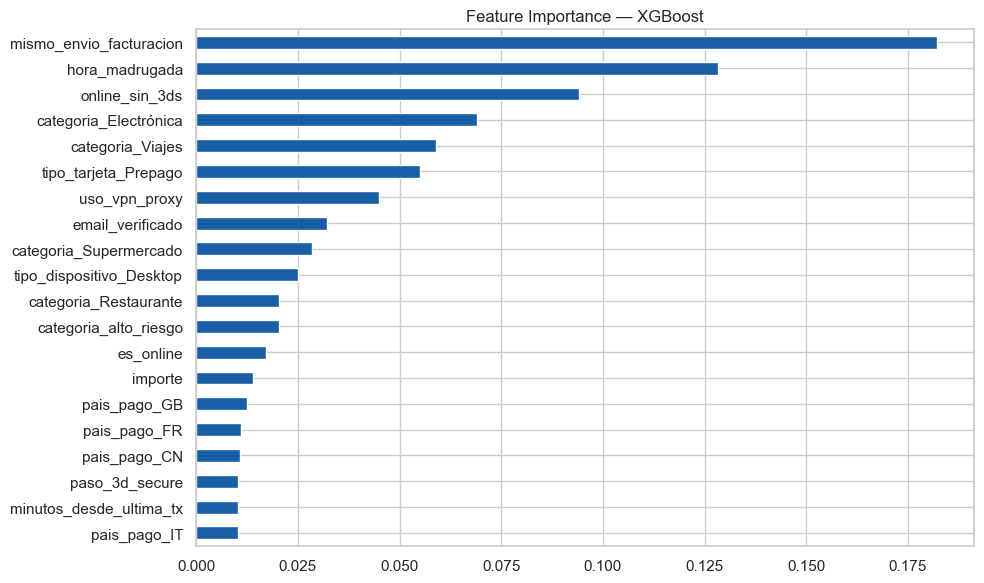

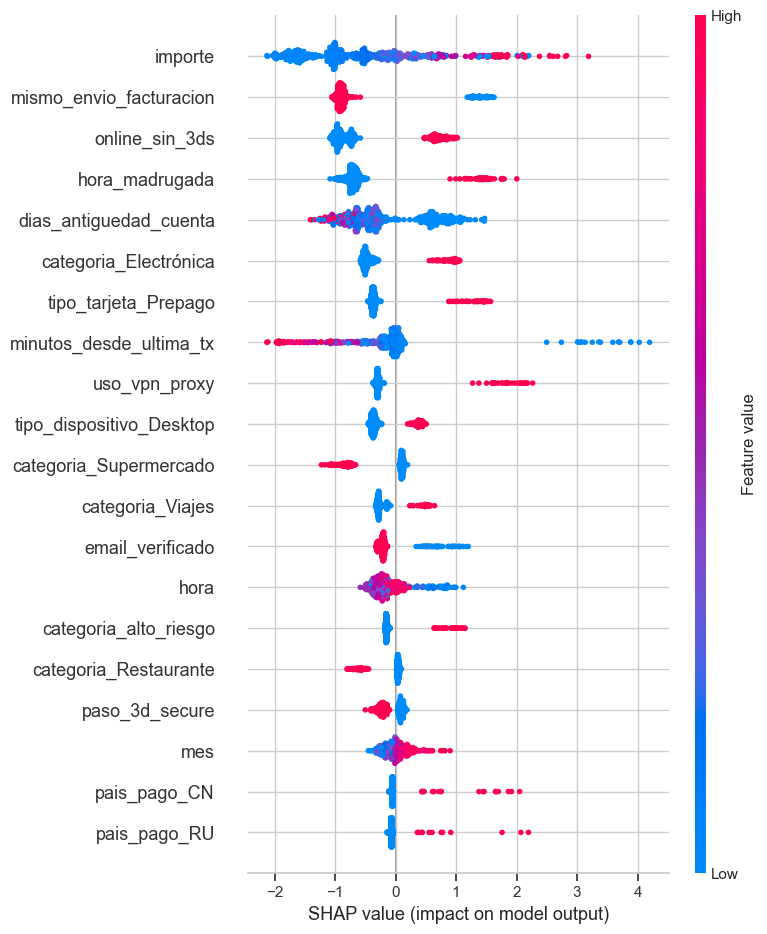

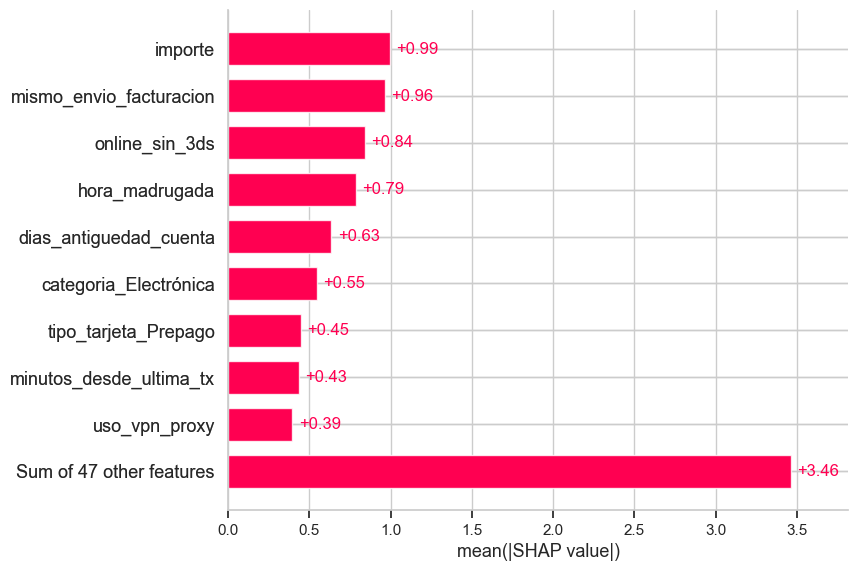

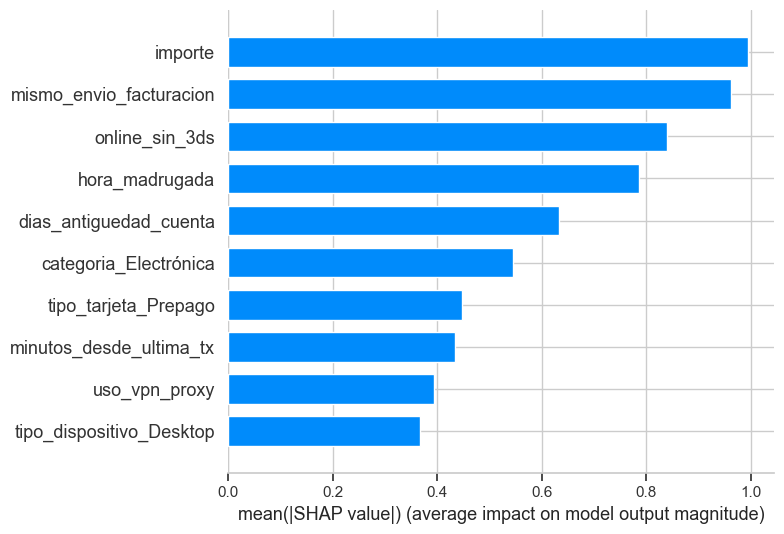

In [20]:
# Extraer modelo
best_model = rs_xgb.best_estimator_
xgb_model = best_model['clf']

# Transformar X_test paso a paso (sin SMOTE)
X_test_fe = feature_engineering(
    X_test,
    paises_alto_riesgo=paises_alto_riesgo,
    categorias_alto_riesgo=categorias_alto_riesgo
)
X_test_transformed = best_model['preprocessor'].transform(X_test_fe)

# Nombres de features tras OHE
ohe_features = best_model['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_features = num_cols + ohe_features + [
    'email_verificado','es_online','mismo_envio_facturacion',
    'uso_vpn_proxy','paso_3d_secure','dia_semana','es_fin_de_semana',
    'mes','pais_alto_riesgo','hora_madrugada','categoria_alto_riesgo',
    'pais_distinto','online_sin_3ds'
]

# Feature Importance nativa XGBoost
xgb_model = best_model['clf']
importances = pd.Series(xgb_model.feature_importances_, index=all_features)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='#185FA5')
ax.set_title('Feature Importance — XGBoost')
plt.tight_layout()
plt.savefig('data/reports/feature_importance.png', dpi=150)
plt.show()

# SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed[:500])
shap.summary_plot(shap_values, X_test_transformed[:500], 
                  feature_names=all_features, show=True)

shap.plots.bar(shap.Explanation(
    values=shap_values,
    feature_names=all_features
))
shap.summary_plot(
    shap_values, 
    X_test_transformed[:500],
    feature_names=all_features,
    max_display=10,  # solo top 10
    plot_type='bar'  # barras en vez de puntos
)